##  Using the Segment Anything Model and GEOBIA to classify vineyard area

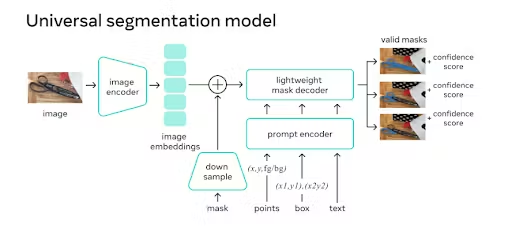

Segment Anything is a new project by Meta to build two important components:

  - A large dataset for image segmentation
  - The Segment Anything Model (SAM) as a basic model for image segmentation


It was introduced in the Segment Anything paper by Alexander Kirillov et al.

This takes inspiration from the field of NLP, where basic models and large data sets (worth billions of tokens) have become commonplace.

The project leads to the creation of a large dataset, a segmentation model, and a data engine, all in a loop.

Since image segmentation is one of the main tasks in computer vision, the authors chose it as a starting point for such large models and datasets. In both science and artificial intelligence, image segmentation has several potential uses. This includes biomedical image analysis, photo editing, and autonomous driving, among others.

To solve any of these problems, you must train specialized models that can only perform one task. This requires extensive domain knowledge and time required to collect specific data, not to mention the hours of training required for deep learning models.

However, the Segment Anything project aims to democratize the world of image segmentation. By open-sourcing both the dataset and the model (SAM for short), it opens up a huge range of possibilities.

## Segment Anything Model

The Segment Anything model is an approach to building a fully automatic image segmentation model with minimal human intervention.

Previous deep learning approaches required specialized training data collection, manual annotation, and hours of training. These approaches work well, but they also require a substantial amount of model retraining when changing the dataset.

With SAM, we now have a generalizable and actionable image segmentation model that can crop almost anything from an image.

SAM is a deep learning model (based on transformers). And as with any deep learning, it was trained on a huge number of images and masks – more than a billion masks across 11 million images, to be precise. That's a considerable number. The dataset is called the Segment Anything dataset, which we will delve into later in this article

Still, how does SAM know which objects to target in an image? The fact is that you don't always know. That's where SAM's callable design comes in.

### SAM as a prompt image segmentation model

SAM can receive instructions from users on which area to target precisely. As of the current version, we can provide three different prompts to SAM:

- When clicking on a point
- Drawing a bounding box
- Drawing a rough mask on an object

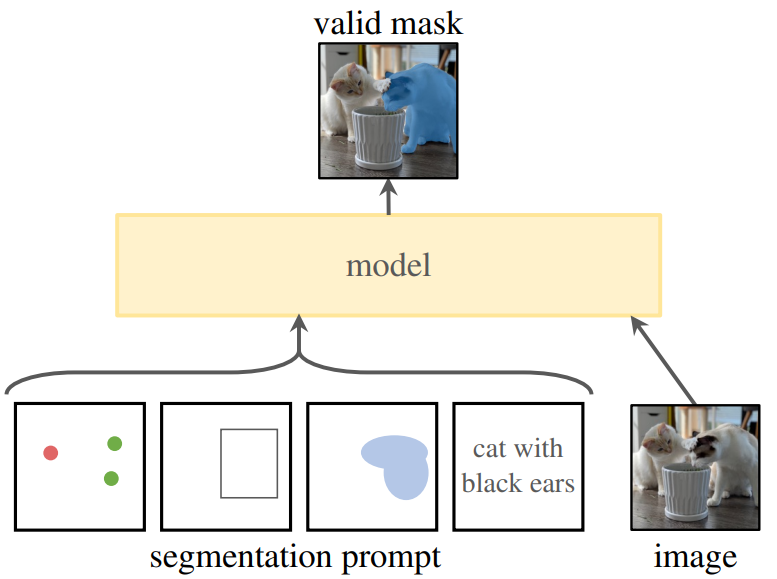

The authors are also working on a version of SAM that accepts text inputs as prompts, just like in the case of language models.

Because SAM was trained on 1 billion masks and allows users to provide warnings, it can always generate a valid mask. What exactly does this mean?

In the case of a click like prompt, sometimes users may click on a person. If for some reason the SAM does not feel confident removing the person's mask, they will attempt to mask the dress. In a similar way, it tries to target other “parts of an object” whenever a prompt is given to SAM.

## How does the Segment Anything model work?

The creators of the Segment Anything Model take inspiration from chat-based Large Language Models, where the request is an integral part of the pipeline.

Also in SAM there are three important mode components:

- An image encoder.
- A prompt encoder.
- A mask decoder.

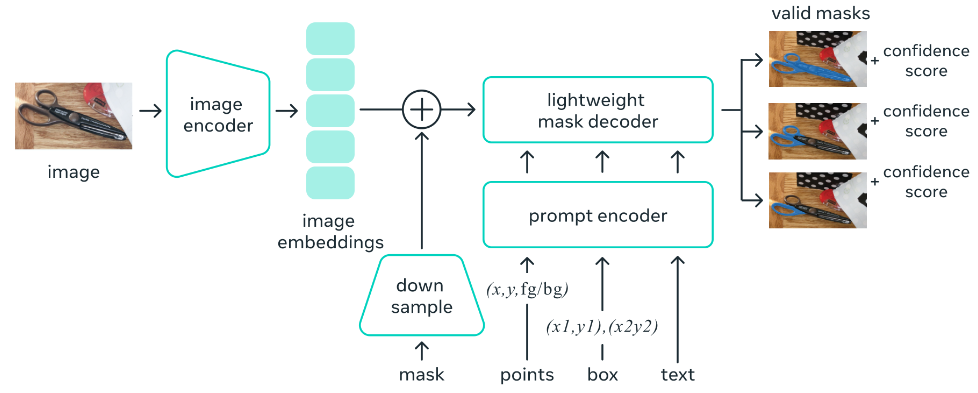

When we provide an image as input to the Segment Anything model, it first passes through an image encoder and produces a single embedding for the entire image.

There is also a prompt encoder for dots, boxes, or text as prompts. For points, the x and y coordinates, along with foreground and background information, become input to the encoder. For boxes, the bounding box coordinates become the input to the encoder, and for text (not released at the time of writing), tokens become the input.

If we provide a mask as input, it directly goes through a downsampling stage. Downsampling happens using 2D convolutional layers. Then the model concatenates it with the image embedding to obtain the final vector.

Any vector that the model obtains from the vector + prompt image embedding passes through a lightweight decoder that creates the final segmentation mask.

We obtain possible valid masks along with a confidence score as a result.

The image encoder is one of the most powerful and essential components of SAM. It is built on a pre-trained Vision Transformer model from MAE. But to maintain real-time performance in browsers, compromises were made.

For the prompt encoder, dots, boxes, and text act as sparse inputs, and masks act as dense inputs. The creators of SAM represent points and bounding boxes using positional encodings and sum them with learned embeddings. For text prompts, SAM uses the CLIP text encoder. For masks like prompts, after downsampling occurs through convolutional layers, the embedding is added element by element with the input image embedding.

## The Segment Anything dataset

The foundation of any innovative deep learning model is the dataset on which it is trained. And it’s no different for the Anything Segmentation Model either.

The Segment Anything dataset contains over 11 million images and 1.1 billion masks. The final dataset is called the SA-1B dataset.

This dataset is certainly needed to train a Segment Anything model. But we also know that such datasets do not exist and that it is impossible to manually annotate so many images.

SAM pre-trained weights are available from the segment-anything open source project.

As of now, there are model weights available for three different scales of Vision Transformer models.

ViT-B SAM

ViT-L SAM

ViT-H SAM

The project also has an installable pip command

Let's then use SAM to segment a high-resolution satellite image downloaded from Google Earth Engine and classify each generated segment using GEOBIA:

First let's download the NAIP image of the area of interest:

In [ ]:
import geopandas as gpd
import json

In [ ]:
import folium
from folium import plugins
from IPython.display import Image
import numpy as np
from matplotlib import pyplot as plt
import cv2

In [ ]:
import ee
ee.Authenticate()
ee.Initialize(project='talvaradol')

We select the coordinates of the area of interest:

In [ ]:
AOI = ee.Geometry.Polygon([[[-101.903489, 20.736243],
          [-101.803922, 20.737896],
          [-101.802756, 20.674544],
          [-101.902282, 20.672896]]])

We filter by date, apply the median to obtain a unique mosaic:

In [ ]:
startDateviz = ee.Date.fromYMD(2017,1,1);
endDateviz = ee.Date.fromYMD(2018,12,29);
collectionviz2 = ee.ImageCollection("USDA/NAIP/DOQQ").filterDate(startDateviz,endDateviz).filterBounds(AOI)

In [ ]:
Naip = collectionviz2.median().clip(AOI).uint8()

So we can export the Image:

In [ ]:
image_naip = Naip.select(['R','G','B']).reproject('EPSG:4326', None, 1)

In [ ]:
task = ee.batch.Export.image.toDrive(image=image_naip,
                                         crs='EPSG:4326',
                                         scale=1,
                                         fileFormat='GeoTIFF',
                                         description='Gto' ,
                                         maxPixels=1e13,
                                         folder='Eagave',
                                         region= AOI)

In [ ]:
task.start()

To assist in collecting samples, we will download a preliminary mapping of viticulture areas:

In [ ]:
collectionUsda = ee.ImageCollection('USDA/NASS/CDL').filter(ee.Filter.date('2020-01-01', '2021-12-31')).first().clip(AOI);

In [ ]:
cropWinesUsda = collectionUsda.select('cropland').eq(69).selfMask();

In [ ]:
cropWinesUsda = cropWinesUsda.select(['cropland']).reproject('EPSG:4326', None, 1)

In [ ]:
task = ee.batch.Export.image.toDrive(image=cropWinesUsda,
                                         crs='EPSG:4326',
                                         scale=1,
                                         fileFormat='GeoTIFF',
                                         description='Gto' ,
                                         maxPixels=1e13,
                                         folder='Eagave',
                                         region= AOI)

In [ ]:
task.start()

With the images downloaded to Google Drive, let's perform the segmentation with SAM:

In [ ]:
!pip install segment-geospatial leafmap localtileserver
!pip install rasterio

We connect to Drive to access the image and plot it with Matplotlib:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Eagave/azul.tif'

In [ ]:
import os
import leafmap
import torch
from samgeo import SamGeo, tms_to_geotiff, get_basemaps
import rasterio
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from rasterio.plot import show

In [ ]:
src = rasterio.open(path)

In [ ]:
img = src.read()

In [ ]:
img.shape

(4, 14039, 20758)

In [ ]:
img = img.transpose([1,2,0])

In [ ]:
img.max()

255

(-0.5, 20757.5, 14038.5, -0.5)

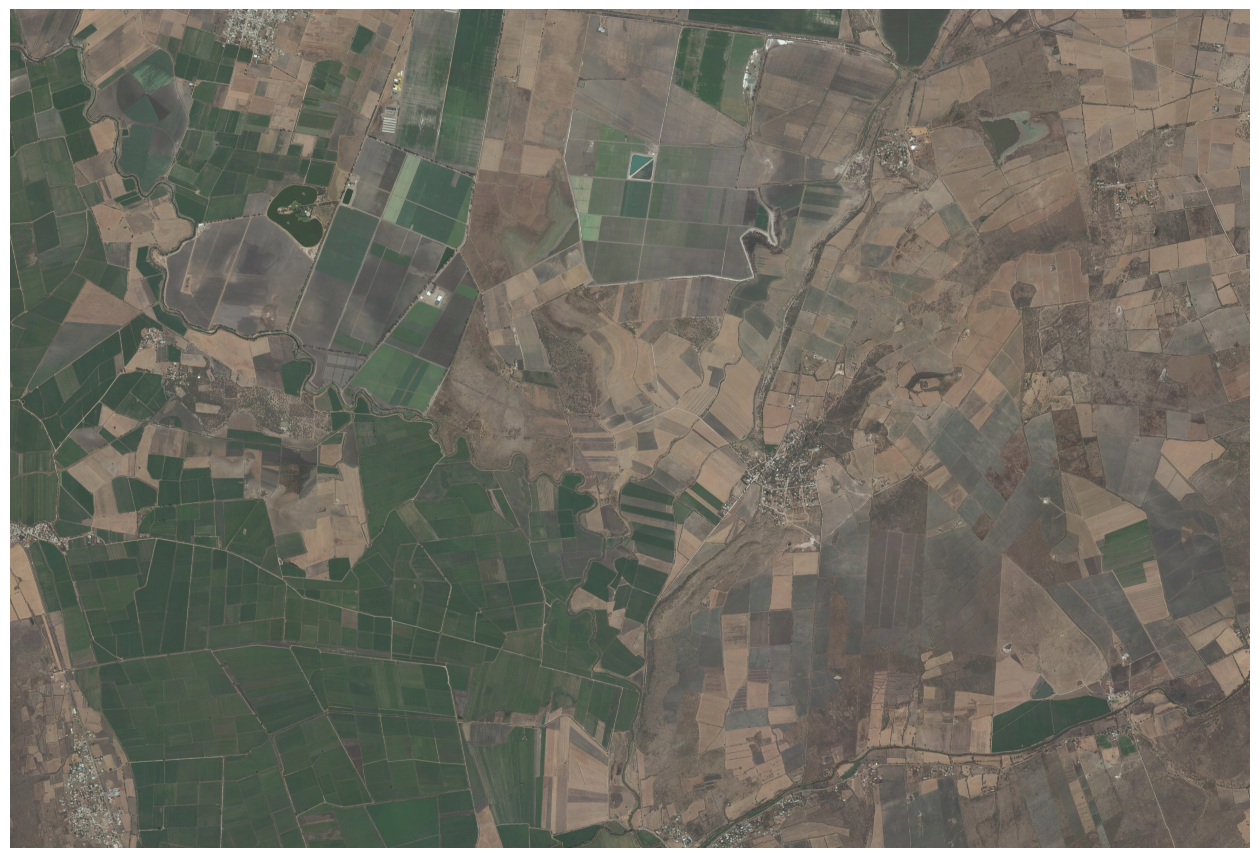

In [ ]:
plt.figure(figsize=[16,16])
plt.imshow(img)
plt.axis('off')

As the image resolution is very high, we can reduce the resolution to facilitate processing:

In [ ]:
from rasterio.enums import Resampling
from rasterio.plot import show

In [ ]:
donwscale_factor = 2
with rasterio.open(path) as dataset:
  data = dataset.read(out_shape=(dataset.count,int(dataset.height / donwscale_factor), int(dataset.width / donwscale_factor)),resampling=Resampling.bilinear)
  transform = dataset.transform * dataset.transform.scale((dataset.width / data.shape[-1]),(dataset.height / data.shape[-2]))
  profile = dataset.profile

profile.update(transform=transform, driver='GTiff', height=data.shape[-2], width=data.shape[-1], crs=dataset.crs, compress='lzw', dtype='uint8')
with rasterio.open(os.path.join('/content/RGB_resampled.tif'),'w', **profile) as dst:
  dst.write(data)

Then we apply SAM to the resulting image:

In [ ]:
image = '/content/RGB_resampled.tif'

In [ ]:
sam = SamGeo(
    model_type="vit_h",
    checkpoint="sam_vit_h_4b8939.pth",
    sam_kwargs=None,
)

Model checkpoint for vit_h not found.


Downloading...
From: https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth
To: /root/.cache/torch/hub/checkpoints/sam_vit_h_4b8939.pth
100%|██████████| 2.56G/2.56G [00:19<00:00, 135MB/s]


In [ ]:
mask = "segment.tif"
sam.generate(
    image, mask, batch=True, foreground=True, erosion_kernel=(3, 3), mask_multiplier=255
)

  1%|          | 2/294 [19:45<47:58:36, 591.50s/it]

We will convert the mask resulting from SAM into a shapefile:

In [ ]:
if not os.path.isdir('/content/Result'):
    os.mkdir('/content/Result')

In [ ]:
shapefile = '/content/Result/segment.shp'
sam.tiff_to_vector(mask, shapefile)

To check the result, let's plot the image along with the segments:

In [ ]:
src_test = rasterio.open(image)

In [ ]:
mask_result = gpd.read_file(shapefile)

In [ ]:
mask_result

,value,geometry
0,255.0,"POLYGON ((-119.96786 36.73463, -119.96783 36.7..."
1,255.0,"POLYGON ((-119.95462 36.73463, -119.95415 36.7..."
2,255.0,"POLYGON ((-119.95408 36.73463, -119.95394 36.7..."
3,255.0,"POLYGON ((-119.98776 36.73461, -119.98772 36.7..."
4,255.0,"POLYGON ((-119.98481 36.73461, -119.98470 36.7..."
...,...,...
2360,255.0,"POLYGON ((-119.94186 36.69201, -119.94185 36.6..."
2361,255.0,"POLYGON ((-119.94057 36.69201, -119.94055 36.6..."
2362,255.0,"POLYGON ((-119.98925 36.69199, -119.98923 36.6..."
2363,255.0,"POLYGON ((-119.98910 36.69201, -119.98896 36.6..."


<Axes: >

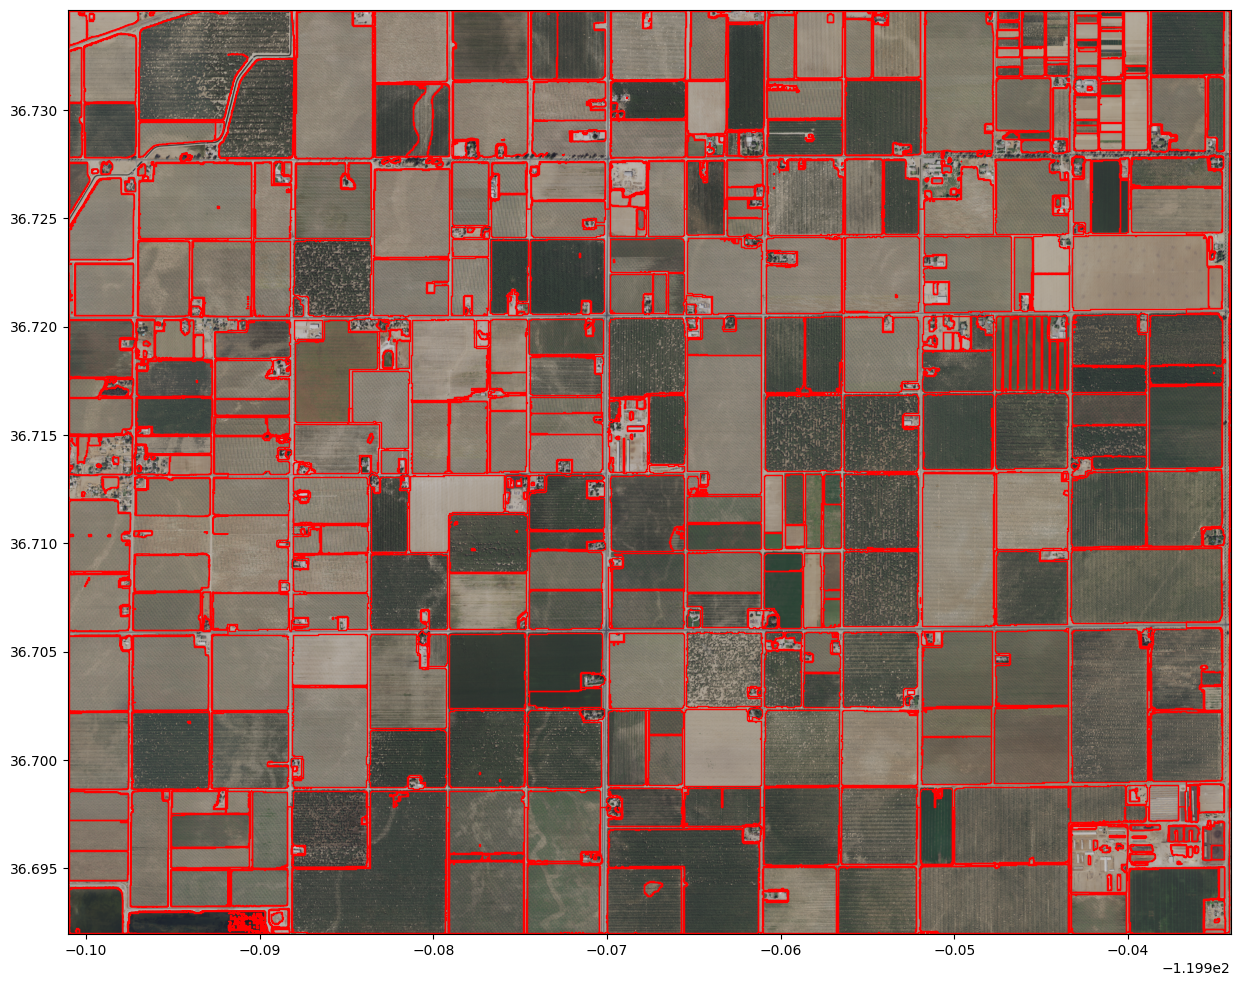

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))
show(src_test, ax=ax)
mask_result.plot(ax=ax, facecolor='none', edgecolor='red')

The next step consists of collecting the segments for each of the classes. There in QGIS, we created 2 vector files of points, one for the viticulture areas and the other for non-viticulture. To facilitate collection, we display the segments along with the auxiliary mapping we downloaded.

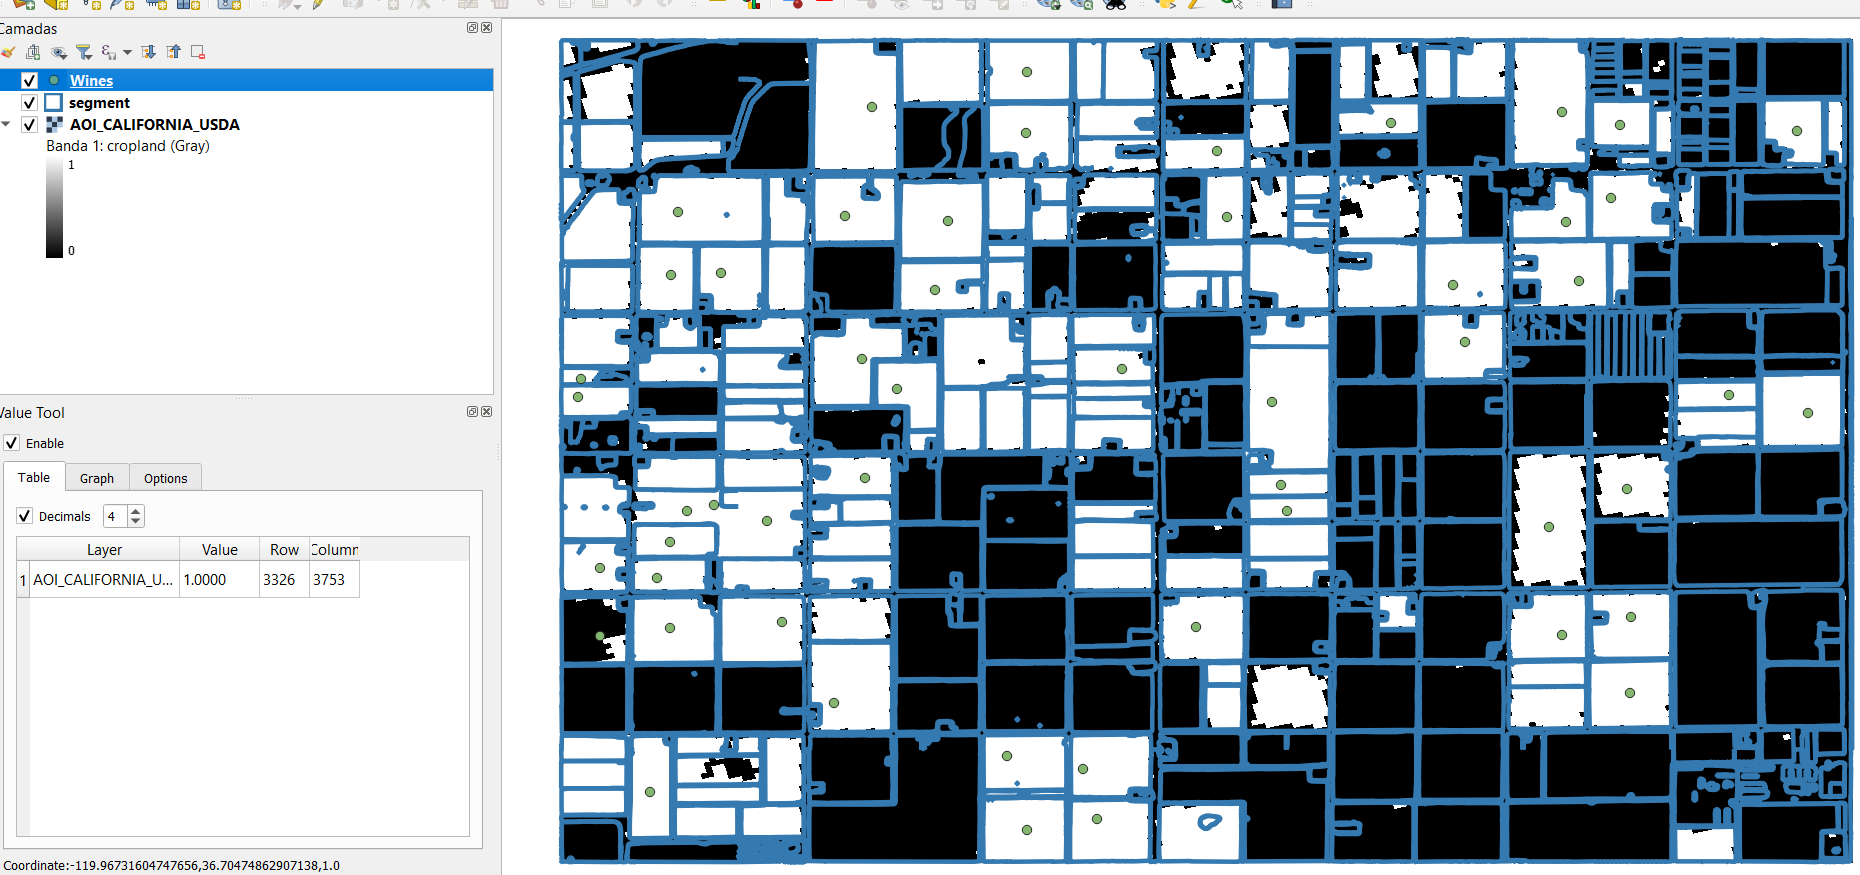

After collecting the points, we will open the two shapefiles and intersect the points with the segments:

In [ ]:
no_wines = gpd.read_file('/content/drive/MyDrive/Datasets/California_Viticulture/No_Wines.shp')
wines = gpd.read_file('/content/drive/MyDrive/Datasets/California_Viticulture/Wines.shp')

In [ ]:
no_wines['class'] = 0
wines['class'] = 1

In [ ]:
samples = pd.concat([no_wines,wines])

In [ ]:
segments = gpd.read_file('/content/drive/MyDrive/Datasets/California_Viticulture/segment.shp')

In [ ]:
segments.reset_index(inplace=True)

In [ ]:
seg_samples = segments.sjoin(samples, how='inner',predicate='intersects').copy()

Here we have the segments of the two classes that will be used in training

<Axes: >

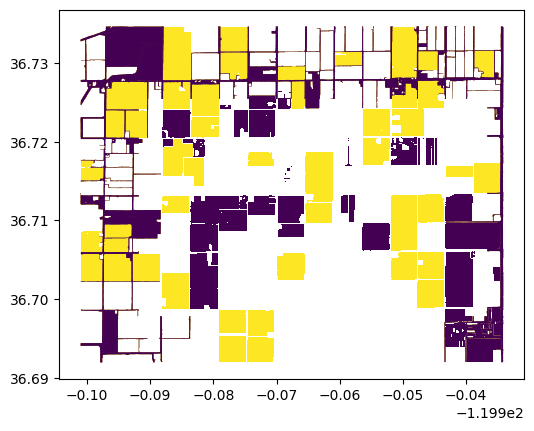

In [ ]:
seg_samples.plot('class',cmap='viridis')

In [ ]:
seg_samples = seg_samples[~seg_samples['index'].duplicated()]

In [ ]:
seg_samples

,index,value,geometry,index_right,id,class
160,160,255.0,"POLYGON ((-119.97884 36.73457, -119.97462 36.7...",35,NaN,1
232,232,255.0,"POLYGON ((-119.96073 36.73139, -119.96060 36.7...",40,NaN,1
248,248,255.0,"POLYGON ((-119.94747 36.73147, -119.94623 36.7...",41,NaN,1
286,286,255.0,"POLYGON ((-119.95164 36.73457, -119.94821 36.7...",34,NaN,1
290,290,255.0,"POLYGON ((-119.93617 36.73156, -119.93615 36.7...",42,NaN,1
...,...,...,...,...,...,...
2209,2209,255.0,"POLYGON ((-119.93477 36.69505, -119.93450 36.6...",39,NaN,0
2315,2315,255.0,"POLYGON ((-119.93543 36.69503, -119.93538 36.6...",29,NaN,0
2316,2316,255.0,"POLYGON ((-119.97191 36.69525, -119.97164 36.6...",20,NaN,1
2334,2334,255.0,"POLYGON ((-119.97723 36.69533, -119.97717 36.6...",18,NaN,1


With these segments selected, we will extract information from the image for each segment. We will use the average of each spectral band of the image and the values of the GLCM properties:

In [ ]:
from skimage.feature import graycomatrix, graycoprops
from rasterio.mask import mask

In [ ]:
src = rasterio.open(path)

In [ ]:
json_dataset = json.loads(seg_samples.to_json())['features']

In [ ]:
X = []
Y = []
for i in range(len(json_dataset)):
  coords = json_dataset[i]['geometry']
  out_image, out_transform = mask(src, [coords], crop=True)
  out_image = out_image.transpose([1,2,0])
  out_image = np.nan_to_num(out_image)

  R_mean = out_image[:,:,0][np.nonzero(out_image[:,:,0])].mean()
  G_mean = out_image[:,:,1][np.nonzero(out_image[:,:,1])].mean()
  B_mean = out_image[:,:,2][np.nonzero(out_image[:,:,2])].mean()



  norm_image = out_image[:,:,0].copy()
  distances = [1]
  angles = [ np.pi/2]
  glcm = graycomatrix(norm_image,
                                distances=distances,
                                angles=angles,
                                symmetric=True,
                                normed=True,
                                levels=256)
  contrast = np.array(graycoprops(glcm, 'contrast')).ravel()[0]
  energy = np.array(graycoprops(glcm, 'energy')).ravel()[0]
  homogeneity = np.array(graycoprops(glcm, 'homogeneity')).ravel()[0]
  correlation = np.array(graycoprops(glcm, 'correlation')).ravel()[0]
  dissimilarity = np.array(graycoprops(glcm, 'dissimilarity')).ravel()[0]
  ASM = np.array(graycoprops(glcm,'ASM')).ravel()[0]

  X.append([R_mean,G_mean,B_mean,contrast,energy,homogeneity,correlation,dissimilarity,ASM])
  Y.append(json_dataset[i]['properties']['class'])

Thus, we generate our set of information that will be divided into training and testing:

In [ ]:
X = np.array(X)
Y = np.array(Y)

In [ ]:
X.shape

(110, 9)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

We apply the random forest classifier to our data:

In [ ]:
clf=RandomForestClassifier(n_estimators=50, n_jobs=8, verbose=3)

In [ ]:
clf.fit(X_train,Y_train)

building tree 1 of 50
building tree 2 of 50
building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50building tree 7 of 50

building tree 8 of 50
building tree 9 of 50building tree 10 of 50
building tree 11 of 50

building tree 12 of 50building tree 13 of 50
building tree 14 of 50

building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50building tree 19 of 50

building tree 20 of 50
building tree 21 of 50
building tree 22 of 50building tree 23 of 50
building tree 24 of 50

building tree 25 of 50
building tree 26 of 50
building tree 27 of 50building tree 28 of 50

building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50

building tree 40 of 50
building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.1s finished


RandomForestClassifier(n_estimators=50, n_jobs=8, verbose=3)

In [ ]:
y_pred=clf.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.0s finished


We observe the accuracy values:

In [ ]:
print("Accuracy on training set: {:.2f}".format(clf.score(X_train, Y_train)))
print("Accuracy on test set: {:.2f}".format(clf.score(X_test, Y_test)))

Accuracy on training set: 1.00
Accuracy on test set: 0.82


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.0s finished


In [ ]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84        18
           1       0.85      0.73      0.79        15

    accuracy                           0.82        33
   macro avg       0.82      0.81      0.81        33
weighted avg       0.82      0.82      0.82        33



The last step is to perform inference on all segments of the image using the trained model. Let's extract the features, but now for all segments:

In [ ]:
json_dataset_full = json.loads(segments.to_json())['features']

In [ ]:
X_pred = []
id_pred = []
for i in range(len(json_dataset_full)):
  coords = json_dataset_full[i]['geometry']
  out_image, out_transform = mask(src, [coords], crop=True)
  out_image = out_image.transpose([1,2,0])
  out_image = np.nan_to_num(out_image)

  R_mean = out_image[:,:,0][np.nonzero(out_image[:,:,0])].mean()
  G_mean = out_image[:,:,1][np.nonzero(out_image[:,:,1])].mean()
  B_mean = out_image[:,:,2][np.nonzero(out_image[:,:,2])].mean()



  norm_image = out_image[:,:,0].copy()
  distances = [1]
  angles = [ np.pi/2]
  glcm = graycomatrix(norm_image,
                                distances=distances,
                                angles=angles,
                                symmetric=True,
                                normed=True,
                                levels=256)
  contrast = np.array(graycoprops(glcm, 'contrast')).ravel()[0]
  energy = np.array(graycoprops(glcm, 'energy')).ravel()[0]
  homogeneity = np.array(graycoprops(glcm, 'homogeneity')).ravel()[0]
  correlation = np.array(graycoprops(glcm, 'correlation')).ravel()[0]
  dissimilarity = np.array(graycoprops(glcm, 'dissimilarity')).ravel()[0]
  ASM = np.array(graycoprops(glcm,'ASM')).ravel()[0]

  X_pred.append([R_mean,G_mean,B_mean,contrast,energy,homogeneity,correlation,dissimilarity,ASM])
  id_pred.append(json_dataset_full[i]['properties']['index'])

In [ ]:
X_pred = np.array(X_pred)
ID = np.array(id_pred)

In [ ]:
X_pred = np.nan_to_num(X_pred)

In [ ]:
img_pred=clf.predict(X_pred)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  16 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done  50 out of  50 | elapsed:    0.0s finished


In [ ]:
ID = ID.astype('uint16')

In [ ]:
segments['class'] = img_pred

In [ ]:
segments

,index,value,geometry,class
0,0,255.0,"POLYGON ((-119.96786 36.73463, -119.96783 36.7...",0
1,1,255.0,"POLYGON ((-119.95462 36.73463, -119.95415 36.7...",0
2,2,255.0,"POLYGON ((-119.95408 36.73463, -119.95394 36.7...",0
3,3,255.0,"POLYGON ((-119.98776 36.73461, -119.98772 36.7...",1
4,4,255.0,"POLYGON ((-119.98481 36.73461, -119.98470 36.7...",1
...,...,...,...,...
2360,2360,255.0,"POLYGON ((-119.94186 36.69201, -119.94185 36.6...",1
2361,2361,255.0,"POLYGON ((-119.94057 36.69201, -119.94055 36.6...",1
2362,2362,255.0,"POLYGON ((-119.98925 36.69199, -119.98923 36.6...",1
2363,2363,255.0,"POLYGON ((-119.98910 36.69201, -119.98896 36.6...",1


Let's plot the result:

In [ ]:
names = { 0:'No_Wine',
          1:'Wine'}

In [ ]:
segments['class_name'] = segments['class'].replace(names)

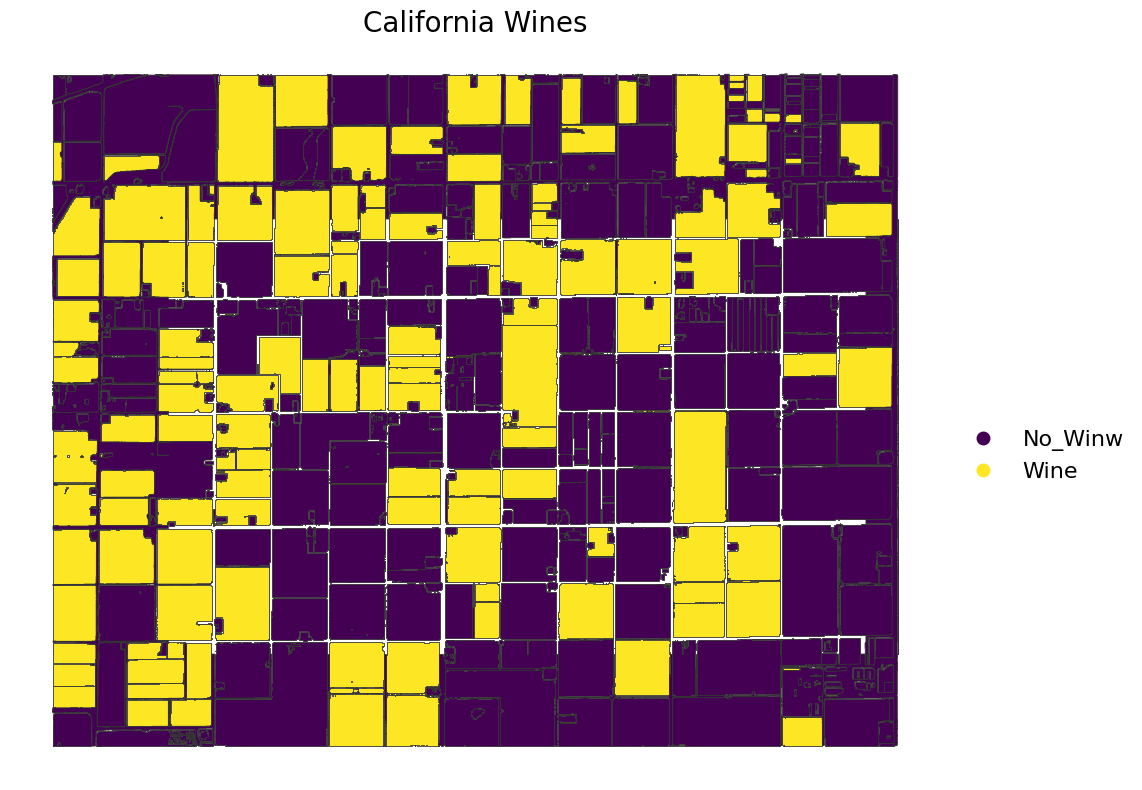

In [ ]:
fig, ax = plt.subplots(1, figsize=(14,8))
segments.plot(column='class_name', categorical=True, cmap='viridis', linewidth=.6, edgecolor='0.2',
         legend=True, legend_kwds={'bbox_to_anchor':(1, 0.5),'loc':'upper left','fontsize':16,'frameon':False}, ax=ax)
ax.axis('off')
ax.set_title('California Wines',fontsize=20)
plt.tight_layout()